<a href="https://colab.research.google.com/github/Sonia1895/PROCESAMIENTO_CLASIFICACION_DATOS/blob/main/Tarea_6_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Objetivo de la tarea**

Implementar un flujo completo de procesamiento y clasificación de señales de audio, cubriendo:

1. Procesamiento de audio: carga de archivos, forma de onda, MFCC y espectrogramas (visto en Clase 7).
2. Extracción de características mediante la transformada wavelet continua (CWT) y comparación entre señales (visto en Clase 8).
3. Clasificación de audio con redes neuronales convolucionales (CNN), comparando dos representaciones de entrada: MFCC y escalogramas de wavelets, siguiendo la metodología del artículo de referencia visto en clase (Dutt, *Audio Classification Using Wavelet Transform and Deep Learning*).

**Dataset utilizado** Se utiliza el *Free Spoken Digit Dataset* (FSDD): 3000 grabaciones de dígitos hablados (0-9) por varios hablantes distintos, en formato `.wav` a 8 kHz. Es un dataset ligero, público y fácil de descargar directamente en Colab (a diferencia de `spoken_mnist` vía `hub`/`deeplake`, que puede presentar problemas de instalación), y contiene la misma naturaleza de datos (dígitos hablados) usada como ejemplo en clase. Repositorio del dataset: https://github.com/Jakobovski/free-spoken-digit-dataset

#Descarga del dataset

In [1]:
import os
import glob

# Clonar el repositorio del dataset (solo se ejecuta una vez por sesión de Colab)
if not os.path.exists('free-spoken-digit-dataset'):
    !git clone --depth 1 https://github.com/Jakobovski/free-spoken-digit-dataset.git

AUDIO_DIR = 'free-spoken-digit-dataset/recordings'
audio_files = sorted(glob.glob(os.path.join(AUDIO_DIR, '*.wav')))
print(f'Total de archivos de audio encontrados: {len(audio_files)}')


Total de archivos de audio encontrados: 3000


In [2]:
# Extraer metadatos (digito y hablante) a partir del nombre de archivo
def parse_filename(path):
    """Extrae el digito (etiqueta) y el nombre del hablante a partir del nombre del archivo."""
    base = os.path.basename(path).replace('.wav', '')
    digito, hablante, indice = base.split('_')
    return int(digito), hablante, int(indice)

digitos = [parse_filename(f)[0] for f in audio_files]
hablantes = [parse_filename(f)[1] for f in audio_files]

print('Digitos unicos:', sorted(set(digitos)))
print('Hablantes unicos:', sorted(set(hablantes)))
print('Muestras por digito:', {d: digitos.count(d) for d in sorted(set(digitos))})

Digitos unicos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Hablantes unicos: ['george', 'jackson', 'lucas', 'nicolas', 'theo', 'yweweler']
Muestras por digito: {0: 300, 1: 300, 2: 300, 3: 300, 4: 300, 5: 300, 6: 300, 7: 300, 8: 300, 9: 300}


#Procesamiento de audio

In [3]:
import librosa
import librosa.display
import IPython.display as ipd

# Cargar un archivo de ejemplo
ejemplo_path = audio_files[0]
y, sr = librosa.load(ejemplo_path, sr=8000)
digito, hablante, _ = parse_filename(ejemplo_path)

print(f'Archivo: {os.path.basename(ejemplo_path)}')
print(f'Digito: {digito} | Hablante: {hablante}')
print(f'Frecuencia de muestreo: {sr} Hz')
print(f'Duracion: {len(y) / sr:.3f} segundos')

ipd.Audio(y, rate=sr)

Archivo: 0_george_0.wav
Digito: 0 | Hablante: george
Frecuencia de muestreo: 8000 Hz
Duracion: 0.298 segundos


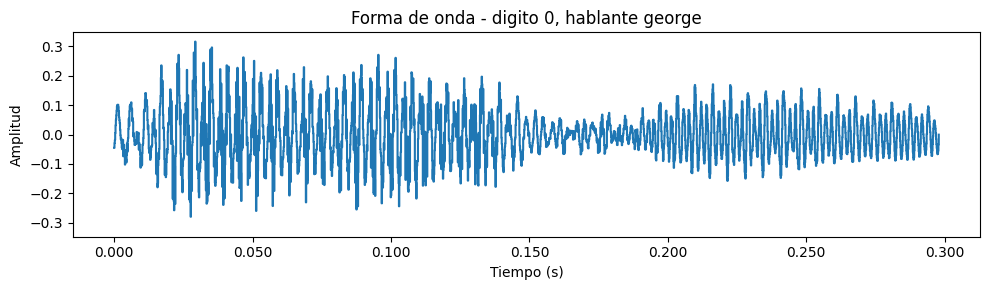

In [4]:
import matplotlib.pyplot as plt

# Carpeta donde se guardaran las figuras generadas
os.makedirs('resultados', exist_ok=True)


# Forma de onda
plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title(f'Forma de onda - digito {digito}, hablante {hablante}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.tight_layout()
plt.savefig('resultados/forma_onda_ejemplo.png', dpi=150)
plt.show()


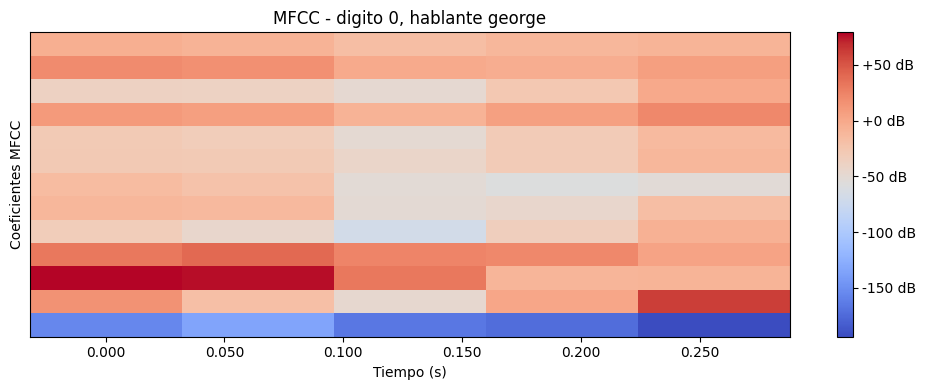

In [5]:
# MFCC (Mel Frequency Cepstral Coefficients)
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs, x_axis='time', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title(f'MFCC - digito {digito}, hablante {hablante}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Coeficientes MFCC')
plt.tight_layout()
plt.savefig('resultados/mfcc_ejemplo.png', dpi=150)
plt.show()

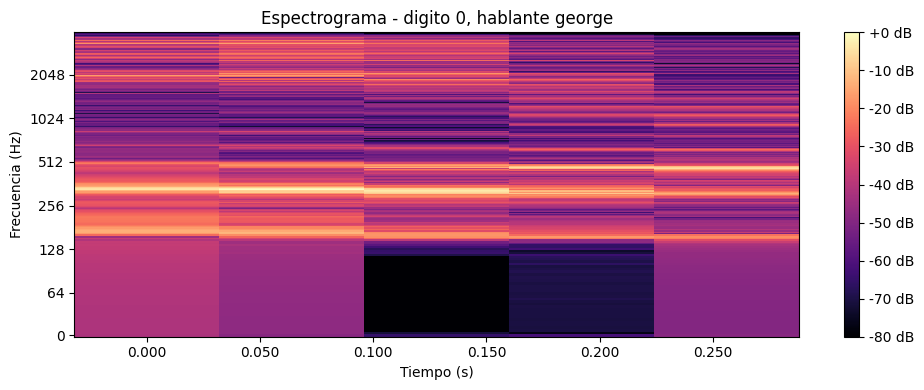

In [6]:
import numpy as np

# Espectrograma
S = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Espectrograma - digito {digito}, hablante {hablante}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Frecuencia (Hz)')
plt.tight_layout()
plt.savefig('resultados/espectrograma_ejemplo.png', dpi=150)
plt.show()

#Comparacion entre distintos hablantes

In [7]:
# Seleccionar dos grabaciones del mismo digito pronunciado por hablantes distintos
digito_objetivo = 5
candidatos = [f for f in audio_files if parse_filename(f)[0] == digito_objetivo]
hablantes_objetivo = sorted(set(parse_filename(f)[1] for f in candidatos))
print('Hablantes disponibles para el digito', digito_objetivo, ':', hablantes_objetivo)

archivo_a = [f for f in candidatos if parse_filename(f)[1] == hablantes_objetivo[0]][0]
archivo_b = [f for f in candidatos if parse_filename(f)[1] == hablantes_objetivo[1]][0]

y_a, sr_a = librosa.load(archivo_a, sr=8000)
y_b, sr_b = librosa.load(archivo_b, sr=8000)

Hablantes disponibles para el digito 5 : ['george', 'jackson', 'lucas', 'nicolas', 'theo', 'yweweler']


In [8]:

ipd.Audio(y_a, rate=sr_a)

In [9]:

ipd.Audio(y_b, rate=sr_b)

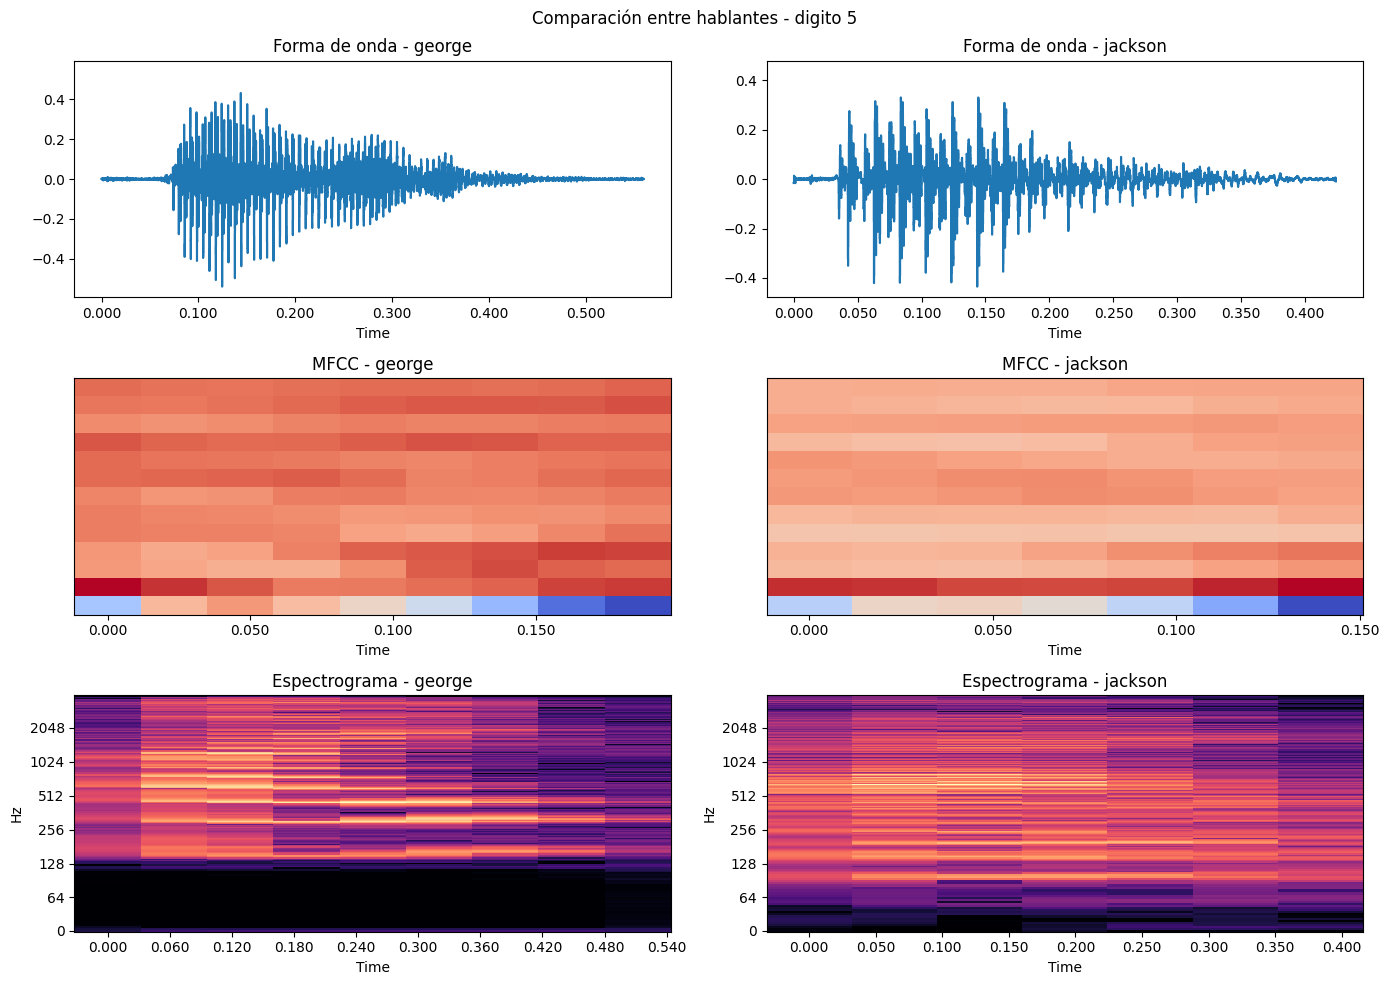

In [10]:
# Comparación visual: forma de onda, MFCC y espectrograma lado a lado
fig, axs = plt.subplots(3, 2, figsize=(14, 10))

librosa.display.waveshow(y_a, sr=sr_a, ax=axs[0, 0])
axs[0, 0].set_title(f'Forma de onda - {hablantes_objetivo[0]}')
librosa.display.waveshow(y_b, sr=sr_b, ax=axs[0, 1])
axs[0, 1].set_title(f'Forma de onda - {hablantes_objetivo[1]}')

mfcc_a = librosa.feature.mfcc(y=y_a, sr=sr_a, n_mfcc=13)
mfcc_b = librosa.feature.mfcc(y=y_b, sr=sr_b, n_mfcc=13)
librosa.display.specshow(mfcc_a, x_axis='time', ax=axs[1, 0])
axs[1, 0].set_title(f'MFCC - {hablantes_objetivo[0]}')
librosa.display.specshow(mfcc_b, x_axis='time', ax=axs[1, 1])
axs[1, 1].set_title(f'MFCC - {hablantes_objetivo[1]}')

S_a = librosa.amplitude_to_db(np.abs(librosa.stft(y_a)), ref=np.max)
S_b = librosa.amplitude_to_db(np.abs(librosa.stft(y_b)), ref=np.max)
librosa.display.specshow(S_a, sr=sr_a, x_axis='time', y_axis='log', ax=axs[2, 0])
axs[2, 0].set_title(f'Espectrograma - {hablantes_objetivo[0]}')
librosa.display.specshow(S_b, sr=sr_b, x_axis='time', y_axis='log', ax=axs[2, 1])
axs[2, 1].set_title(f'Espectrograma - {hablantes_objetivo[1]}')

plt.suptitle(f'Comparación entre hablantes - digito {digito_objetivo}')
plt.tight_layout()
plt.savefig('resultados/comparacion_hablantes.png', dpi=150)
plt.show()


#Extracción de características mediante wavelets

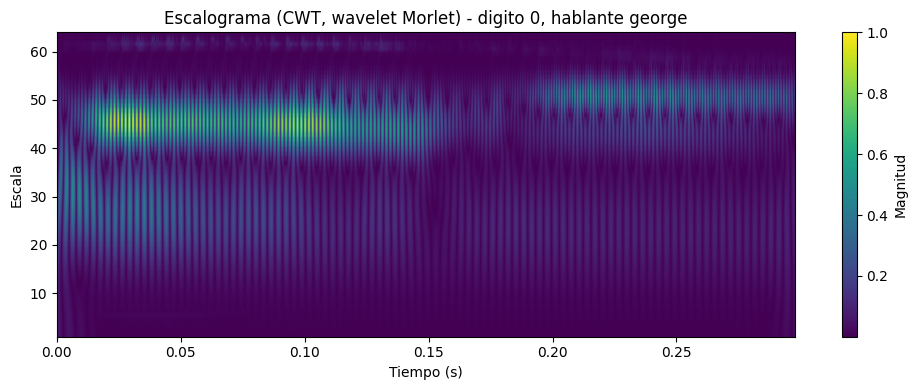

In [11]:
import pywt

def calcular_escalograma(y, escalas=np.arange(1, 65), wavelet='morl'):
    """Calcula el escalograma (magnitud de la CWT) de una señal de audio."""
    coeficientes, _ = pywt.cwt(y, escalas, wavelet)
    return np.abs(coeficientes)

escalograma_ejemplo = calcular_escalograma(y)

plt.figure(figsize=(10, 4))
plt.imshow(escalograma_ejemplo, extent=[0, len(y) / sr, 1, 64], cmap='viridis', aspect='auto')
plt.colorbar(label='Magnitud')
plt.title(f'Escalograma (CWT, wavelet Morlet) - digito {digito}, hablante {hablante}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Escala')
plt.tight_layout()
plt.savefig('resultados/escalograma_ejemplo.png', dpi=150)
plt.show()

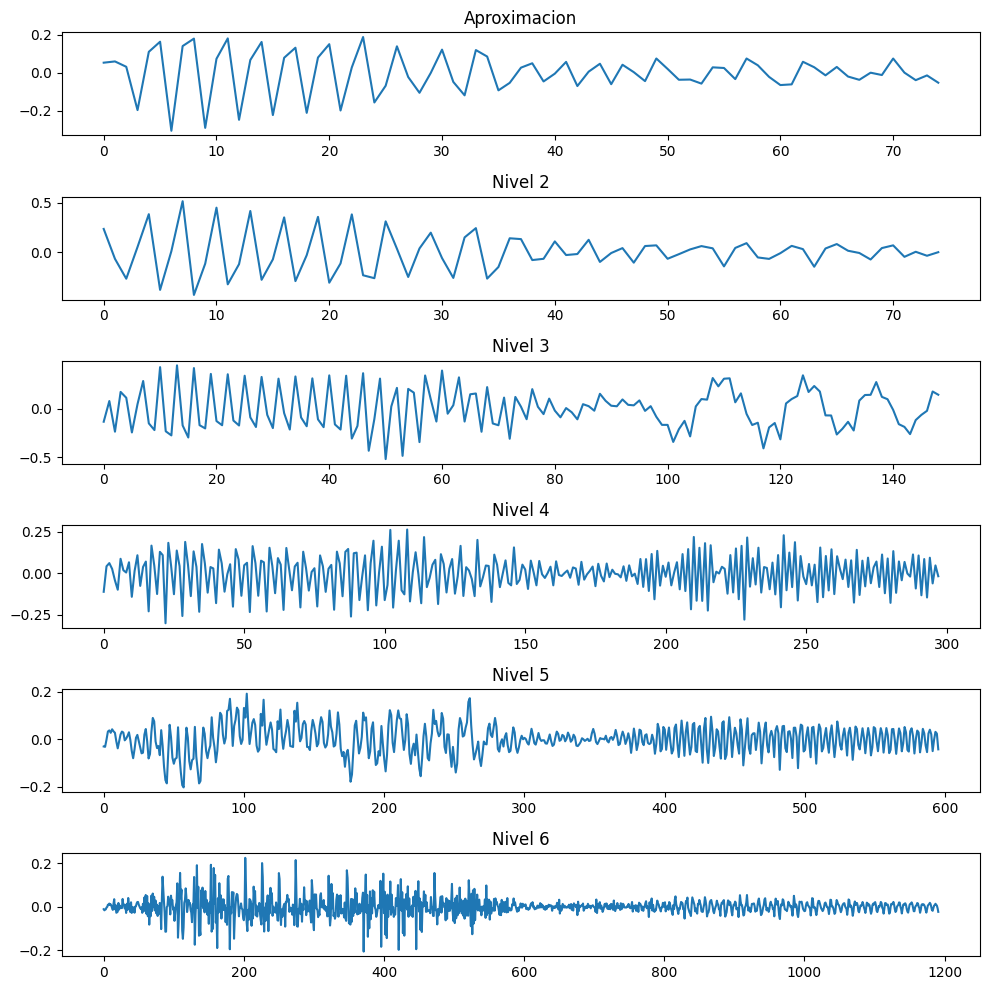

In [12]:
# Descomposición wavelet discreta (DWT)
coeficientes_dwt = pywt.wavedec(y, 'db1', level=5)

fig, axs = plt.subplots(len(coeficientes_dwt), 1, figsize=(10, 10))
for i, coef in enumerate(coeficientes_dwt):
    axs[i].plot(coef)
    axs[i].set_title(f'Nivel {i + 1}' if i > 0 else 'Aproximacion')
plt.tight_layout()
plt.savefig('resultados/dwt_niveles.png', dpi=150)
plt.show()

#Preparación del dataset para clasificación

In [13]:
from skimage.transform import resize

IMG_SIZE = 32          # Tamaño fijo de las imagenes de entrada a la CNN
FIXED_LEN = 4000        # Longitud fija de la señal de audio (en muestras) tras recorte/relleno
N_POR_CLASE = 150       # Cantidad de muestras por digito a utilizar (max 300 disponibles por clase aprox.)

def ajustar_longitud(y, longitud=FIXED_LEN):
    """Recorta o rellena con ceros la señal para que todas tengan la misma longitud."""
    if len(y) < longitud:
        return np.pad(y, (0, longitud - len(y)))
    return y[:longitud]

def extraer_mfcc_imagen(path):
    """Convierte un archivo de audio en una imagen de MFCC normalizada de tamano fijo."""
    y, sr = librosa.load(path, sr=8000)
    y = ajustar_longitud(y)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    mfcc = resize(mfcc, (IMG_SIZE, IMG_SIZE))
    mfcc = (mfcc - mfcc.min()) / (mfcc.max() - mfcc.min() + 1e-9)
    return mfcc.astype('float32')

def extraer_escalograma_imagen(path):
    """Convierte un archivo de audio en una imagen de escalograma (CWT) normalizada de tamano fijo."""
    y, sr = librosa.load(path, sr=8000)
    y = ajustar_longitud(y)
    escalograma = calcular_escalograma(y, escalas=np.arange(1, 33))
    escalograma = resize(escalograma, (IMG_SIZE, IMG_SIZE))
    escalograma = (escalograma - escalograma.min()) / (escalograma.max() - escalograma.min() + 1e-9)
    return escalograma.astype('float32')

In [14]:
# Seleccionar un subconjunto balanceado de archivos por dígito
from collections import defaultdict

archivos_por_digito = defaultdict(list)
for f in audio_files:
    d, _, _ = parse_filename(f)
    archivos_por_digito[d].append(f)

archivos_seleccionados = []
for d in sorted(archivos_por_digito):
    archivos_seleccionados.extend(archivos_por_digito[d][:N_POR_CLASE])

print(f'Total de archivos seleccionados: {len(archivos_seleccionados)}')

Total de archivos seleccionados: 1500


In [15]:
# Extracción de características para todo el subconjunto
X_mfcc, X_wavelet, y_labels = [], [], []

for path in archivos_seleccionados:
    digito, _, _ = parse_filename(path)
    X_mfcc.append(extraer_mfcc_imagen(path))
    X_wavelet.append(extraer_escalograma_imagen(path))
    y_labels.append(digito)

X_mfcc = np.array(X_mfcc)[..., np.newaxis]
X_wavelet = np.array(X_wavelet)[..., np.newaxis]
y_labels = np.array(y_labels)

print('Forma X_mfcc:', X_mfcc.shape)
print('Forma X_wavelet:', X_wavelet.shape)
print('Forma y_labels:', y_labels.shape)


Forma X_mfcc: (1500, 32, 32, 1)
Forma X_wavelet: (1500, 32, 32, 1)
Forma y_labels: (1500,)


In [16]:
# División en conjuntos de entrenamiento y prueba (los mismos indices para ambas representaciones,
# para que la comparación entre modelos sea justa)

import tensorflow as tf
from sklearn.model_selection import train_test_split

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

indices = np.arange(len(y_labels))
idx_train, idx_test = train_test_split(
    indices, test_size=0.2, random_state=SEED, stratify=y_labels
)

Xm_train, Xm_test = X_mfcc[idx_train], X_mfcc[idx_test]
Xw_train, Xw_test = X_wavelet[idx_train], X_wavelet[idx_test]
y_train, y_test = y_labels[idx_train], y_labels[idx_test]

print('Entrenamiento:', Xm_train.shape[0], 'muestras')
print('Prueba:', Xm_test.shape[0], 'muestras')


Entrenamiento: 1200 muestras
Prueba: 300 muestras


#Modelo de clasificación (CNN)

Se define una arquitectura CNN sencilla y se entrena **dos veces por separado**: una vez usando MFCC como entrada y otra usando escalogramas de wavelets como entrada. Ambos modelos comparten la misma arquitectura, para que la comparación de resultados se deba a la representación de entrada y no a diferencias del modelo.

In [17]:
def construir_modelo_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 1), n_clases=10):
    """Arquitectura CNN simple para clasificacion de digitos hablados."""
    modelo = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(n_clases, activation='softmax')
    ])
    modelo.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelo

EPOCHS = 20
BATCH_SIZE = 16

In [18]:
# Entrenamiento del modelo basado en MFCC
from tensorflow.keras import layers, models

modelo_mfcc = construir_modelo_cnn()
historial_mfcc = modelo_mfcc.fit(
    Xm_train, y_train,
    validation_data=(Xm_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.1025 - loss: 2.3108 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1475 - loss: 2.2900 - val_accuracy: 0.1867 - val_loss: 2.2614
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.1875 - loss: 2.2185 - val_accuracy: 0.2967 - val_loss: 2.1238
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2925 - loss: 2.0005 - val_accuracy: 0.4433 - val_loss: 1.7837
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4092 - loss: 1.6962 - val_accuracy: 0.6567 - val_loss: 1.4308
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5367 - loss: 1.3827 - val_accuracy: 0.7867 - val_loss: 1.0430
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6175 - loss: 1.1233 - val_accuracy: 0.8267 - val_loss: 0.7747
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6758 - loss: 0.9462 - val_accuracy: 0.8900 - v

In [19]:
# Entrenamiento del modelo basado en escalogramas de wavelets
modelo_wavelet = construir_modelo_cnn()
historial_wavelet = modelo_wavelet.fit(
    Xw_train, y_train,
    validation_data=(Xw_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)



Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3217 - loss: 1.8835 - val_accuracy: 0.5333 - val_loss: 1.3241
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5283 - loss: 1.2997 - val_accuracy: 0.6800 - val_loss: 0.9270
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6483 - loss: 0.9902 - val_accuracy: 0.7867 - val_loss: 0.6637
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7350 - loss: 0.7658 - val_accuracy: 0.8133 - val_loss: 0.5436
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7717 - loss: 0.6504 - val_accuracy: 0.8567 - val_loss: 0.4282
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8133 - loss: 0.5531 - val_accuracy: 0.8400 - val_loss: 0.4694
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8375 - loss: 0.4685 - val_accuracy: 0.8833 - val_loss: 0.3582
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8517 - loss: 0.4144 - val_accuracy: 0.8900 - v

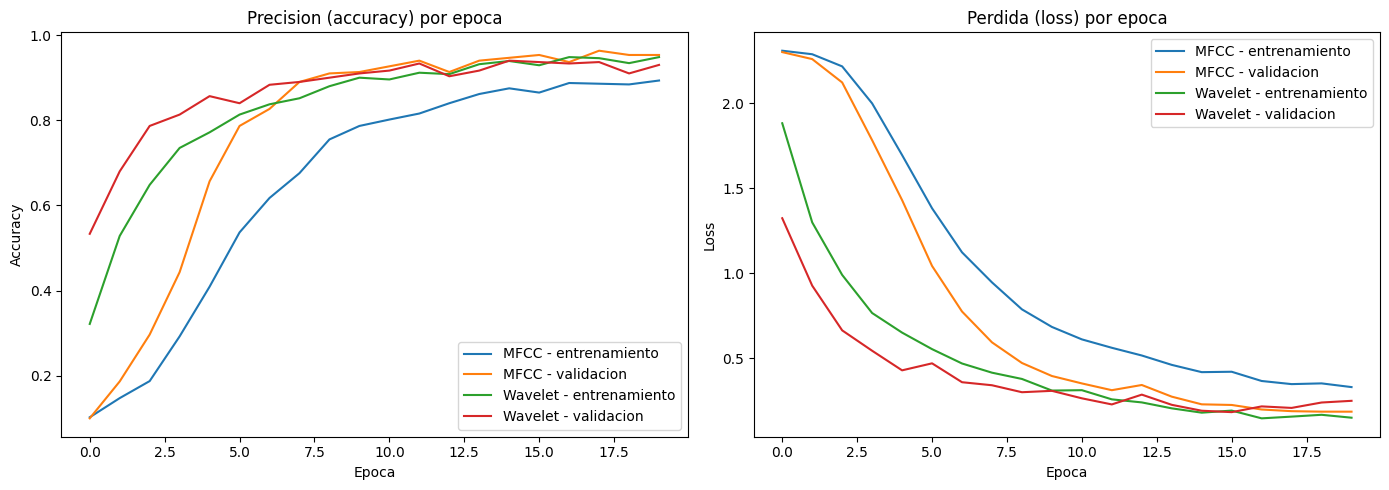

In [20]:
# Curvas de entrenamiento de ambos modelos
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(historial_mfcc.history['accuracy'], label='MFCC - entrenamiento')
axs[0].plot(historial_mfcc.history['val_accuracy'], label='MFCC - validacion')
axs[0].plot(historial_wavelet.history['accuracy'], label='Wavelet - entrenamiento')
axs[0].plot(historial_wavelet.history['val_accuracy'], label='Wavelet - validacion')
axs[0].set_title('Precision (accuracy) por epoca')
axs[0].set_xlabel('Epoca')
axs[0].set_ylabel('Accuracy')
axs[0].legend()

axs[1].plot(historial_mfcc.history['loss'], label='MFCC - entrenamiento')
axs[1].plot(historial_mfcc.history['val_loss'], label='MFCC - validacion')
axs[1].plot(historial_wavelet.history['loss'], label='Wavelet - entrenamiento')
axs[1].plot(historial_wavelet.history['val_loss'], label='Wavelet - validacion')
axs[1].set_title('Perdida (loss) por epoca')
axs[1].set_xlabel('Epoca')
axs[1].set_ylabel('Loss')
axs[1].legend()

plt.tight_layout()
plt.savefig('resultados/curvas_entrenamiento.png', dpi=150)
plt.show()

#Evaluación y comparación de resultados

In [21]:
# Evaluación en el conjunto de prueba
loss_mfcc, acc_mfcc = modelo_mfcc.evaluate(Xm_test, y_test, verbose=0)
loss_wavelet, acc_wavelet = modelo_wavelet.evaluate(Xw_test, y_test, verbose=0)

print(f'Modelo MFCC     -> accuracy: {acc_mfcc:.4f} | loss: {loss_mfcc:.4f}')
print(f'Modelo Wavelet  -> accuracy: {acc_wavelet:.4f} | loss: {loss_wavelet:.4f}')

Modelo MFCC     -> accuracy: 0.9533 | loss: 0.1848
Modelo Wavelet  -> accuracy: 0.9300 | loss: 0.2487


In [23]:
# Reporte de clasificación detallado (precisión, recall, f1-score por clase)
from sklearn.metrics import classification_report, confusion_matrix

pred_mfcc = np.argmax(modelo_mfcc.predict(Xm_test, verbose=0), axis=1)
pred_wavelet = np.argmax(modelo_wavelet.predict(Xw_test, verbose=0), axis=1)

print('--- Reporte de clasificacion - MFCC ---')
print(classification_report(y_test, pred_mfcc, digits=3))

print('--- Reporte de clasificacion - Wavelet ---')
print(classification_report(y_test, pred_wavelet, digits=3))

--- Reporte de clasificacion - MFCC ---
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        30
           1      0.933     0.933     0.933        30
           2      1.000     1.000     1.000        30
           3      0.935     0.967     0.951        30
           4      1.000     0.933     0.966        30
           5      0.938     1.000     0.968        30
           6      0.897     0.867     0.881        30
           7      0.966     0.933     0.949        30
           8      0.875     0.933     0.903        30
           9      1.000     0.967     0.983        30

    accuracy                          0.953       300
   macro avg      0.954     0.953     0.953       300
weighted avg      0.954     0.953     0.953       300

--- Reporte de clasificacion - Wavelet ---
              precision    recall  f1-score   support

           0      1.000     0.900     0.947        30
           1      0.938     1.000     0.968      

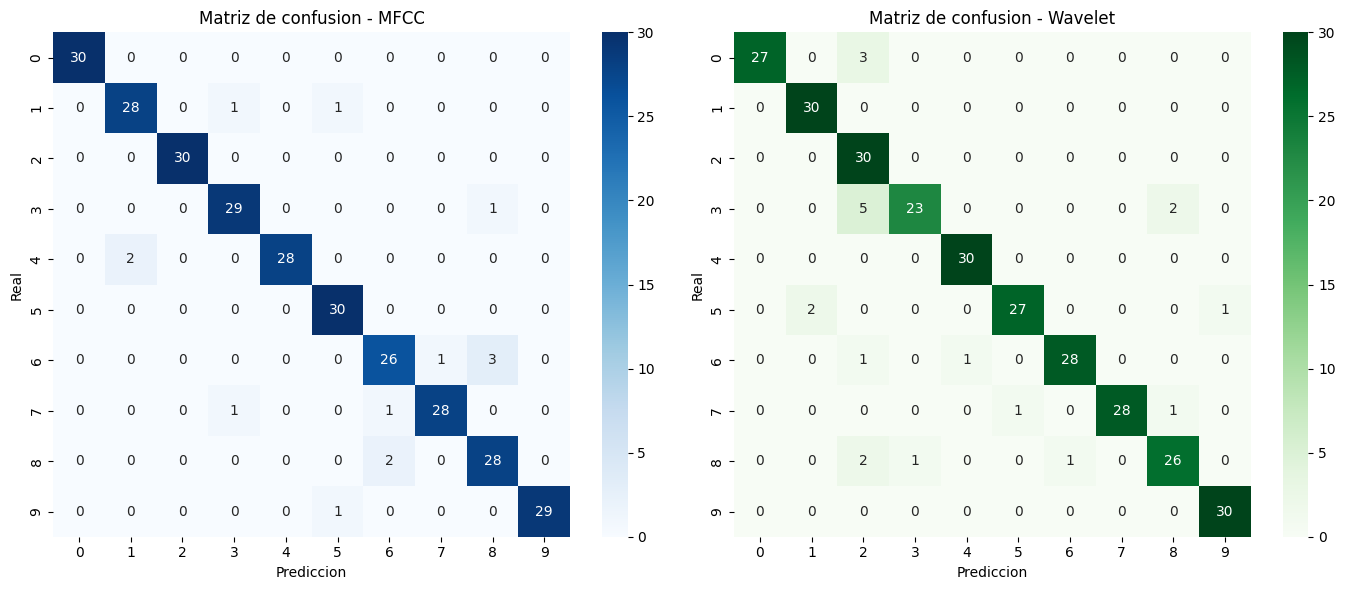

In [25]:
# Matrices de confusion
import seaborn as sns

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

cm_mfcc = confusion_matrix(y_test, pred_mfcc)
sns.heatmap(cm_mfcc, annot=True, fmt='d', cmap='Blues', ax=axs[0])
axs[0].set_title('Matriz de confusion - MFCC')
axs[0].set_xlabel('Prediccion')
axs[0].set_ylabel('Real')

cm_wavelet = confusion_matrix(y_test, pred_wavelet)
sns.heatmap(cm_wavelet, annot=True, fmt='d', cmap='Greens', ax=axs[1])
axs[1].set_title('Matriz de confusion - Wavelet')
axs[1].set_xlabel('Prediccion')
axs[1].set_ylabel('Real')

plt.tight_layout()
plt.savefig('resultados/matrices_confusion.png', dpi=150)
plt.show()

In [26]:
# Tabla resumen comparativa entre ambos enfoques
import pandas as pd

resumen = pd.DataFrame({
    'Representacion': ['MFCC', 'Wavelet (escalograma)'],
    'Accuracy (test)': [acc_mfcc, acc_wavelet],
    'Loss (test)': [loss_mfcc, loss_wavelet]
})
resumen

,Representacion,Accuracy (test),Loss (test)
0,MFCC,0.953333,0.184770
1,Wavelet (escalograma),0.930000,0.248657
